In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Устанавливаем тему, контекст (размер шрифтов) и палитру для всех графиков
sns.set_theme(style="whitegrid", context="talk", palette="viridis")

# Устанавливаем дефолтный размер фигуры (в дюймах)
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Загрузка данных и первичная обработка
bookings = pd.read_csv('bookings.csv', sep=';')

In [32]:
# Приведение названий колонок к единому стандарту (snake_case)
bookings.columns = bookings.columns.str.lower().str.replace(' ', '_')
display(bookings.head())
bookings.info()

,hotel,is_canceled,lead_time,arrival_full_date,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,...,adults,children,babies,meal,country,reserved_room_type,assigned_room_type,customer_type,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015-07-01,2015,July,27,1,0,0,...,2,0.0,0,BB,PRT,C,C,Transient,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015-07-01,2015,July,27,1,0,0,...,2,0.0,0,BB,PRT,C,C,Transient,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015-07-01,2015,July,27,1,0,1,...,1,0.0,0,BB,GBR,A,C,Transient,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015-07-01,2015,July,27,1,0,1,...,1,0.0,0,BB,GBR,A,A,Transient,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015-07-01,2015,July,27,1,0,2,...,2,0.0,0,BB,GBR,A,A,Transient,Check-Out,2015-07-03


<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 21 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   hotel                      119390 non-null  str    
 1   is_canceled                119390 non-null  int64  
 2   lead_time                  119390 non-null  int64  
 3   arrival_full_date          119390 non-null  str    
 4   arrival_date_year          119390 non-null  int64  
 5   arrival_date_month         119390 non-null  str    
 6   arrival_date_week_number   119390 non-null  int64  
 7   arrival_date_day_of_month  119390 non-null  int64  
 8   stays_in_weekend_nights    119390 non-null  int64  
 9   stays_in_week_nights       119390 non-null  int64  
 10  stays_total_nights         119390 non-null  int64  
 11  adults                     119390 non-null  int64  
 12  children                   119386 non-null  float64
 13  babies                     119390 non-nu

In [ ]:
# 2. Демографический анализ
# Топ-5 стран по доле успешных бронирований
top_successful_countries = round(bookings.query('is_canceled == 0') \
    .country.value_counts(normalize=True) \
    .head(5) * 100, 2)

country
PRT    28.19
GBR    12.95
FRA    11.35
ESP     8.55
DEU     8.12
Name: proportion, dtype: float64

In [ ]:
# 3. Анализ паттернов проживания
# Средняя длительность проживания по типу отеля
avg_stays_by_hotel = bookings.groupby('hotel') \
    .agg({'stays_total_nights': 'mean'}) \
    .round(2)

,stays_total_nights
hotel,
City Hotel,2.98
Resort Hotel,4.32


In [ ]:
# 4. Анализ овербукинга
# Количество случаев замены типа номера
overbooking_count = bookings.query('assigned_room_type != reserved_room_type').shape[0]

14917

In [ ]:
# 5. Сезонность отмен
# Количество отмен City Hotel по годам и месяцам
cancellations_seasonality = bookings.query('is_canceled == 1 and hotel == "City Hotel"') \
    .groupby(['arrival_date_year', 'arrival_date_month']) \
    .size()

arrival_date_year  arrival_date_month
2015               August                1232
                   December               668
                   July                   939
                   November               301
                   October               1321
                   September             1543
2016               April                 1539
                   August                1247
                   December              1072
                   February               930
                   January                438
                   July                  1043
                   June                  1720
                   March                 1108
                   May                   1436
                   November              1360
                   October               1947
                   September             1567
2017               April                 1926
                   August                1123
                   February               

In [ ]:
# 6. Демография: Возраст и дети
# Среднее количество гостей разных возрастных групп
mean_guests_age = bookings[['adults', 'children', 'babies']].mean()

adults      1.856403
children    0.103890
babies      0.007949
dtype: float64

In [ ]:
# Создание колонки с общим числом детей
bookings['total_kids'] = bookings['children'].fillna(0) + bookings['babies'].fillna(0)
# Пересортировка колонок для удобства (total_kids ставим рядом с остальными возрастами)
bookings = bookings[['hotel', 'is_canceled', 'lead_time', 'arrival_full_date',
       'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'stays_total_nights', 'adults', 'children',
       'babies', 'total_kids', 'meal', 'country', 'reserved_room_type', 'assigned_room_type',
       'customer_type', 'reservation_status', 'reservation_status_date']]

# Среднее число детей по типам отелей
avg_kids_by_hotel = bookings.groupby('hotel')['total_kids'].mean()

hotel
City Hotel      0.096307
Resort Hotel    0.142586
Name: total_kids, dtype: float64

In [40]:
# 7. Анализ оттока (Churn Rate) по наличию детей
churn_adults_only = round(bookings.query('adults > 0 and total_kids == 0')['is_canceled'].mean() * 100, 2)
churn_with_kids = round(bookings.query('adults > 0 and total_kids > 0')['is_canceled'].mean() * 100, 2)
display(churn_adults_only)
display(churn_with_kids)

np.float64(37.26)

np.float64(34.86)

In [41]:
# 8. Анализ оттока при овербукинге (Выявление Data Leakage)
churn_replaced_room = round(bookings.query('assigned_room_type != reserved_room_type')['is_canceled'].mean() * 100, 2)
churn_assigned_room = round(bookings.query('assigned_room_type == reserved_room_type')['is_canceled'].mean() * 100, 2)
display(churn_replaced_room)
display(churn_assigned_room)

np.float64(5.38)

np.float64(41.56)

/var/folders/fy/hf0v9l_j1mn907s1ztzmwcp00000gp/T/ipykernel_37101/2911287661.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=churn_by_lead_time.index, y=churn_by_lead_time.values, palette='viridis')


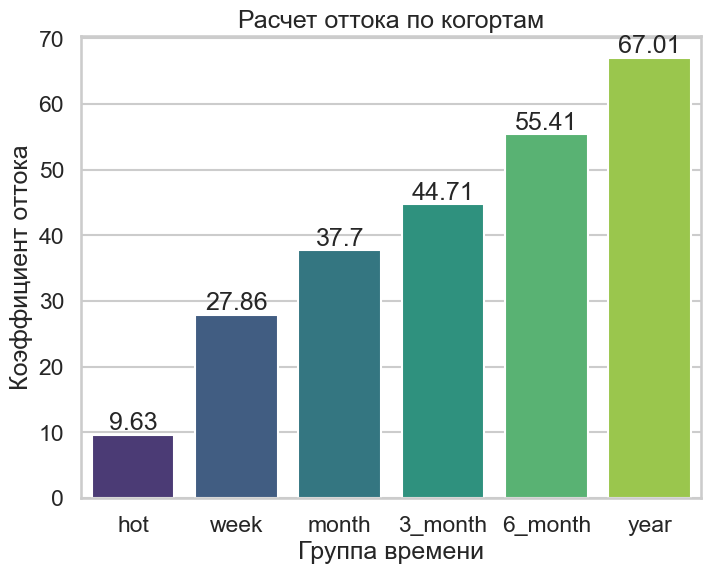

In [42]:
# 9. Когортный анализ горизонта планирования (Lead Time)
# Разбивка времени от брони до заезда на когорты
bookings['lead_time_cohort'] = pd.cut(
    bookings['lead_time'], 
    bins=[-1, 7, 30, 90, 180, 360, bookings['lead_time'].max()], 
    labels=['hot', 'week', 'month', '3_month', '6_month', 'year']
)
# Расчет оттока по когортам
churn_by_lead_time = round(bookings.groupby('lead_time_cohort')['is_canceled'].mean() * 100, 2)
plt.figure(figsize=(8,6))
ax = sns.barplot(x=churn_by_lead_time.index, y=churn_by_lead_time.values, palette='viridis')
plt.title('Расчет оттока по когортам')
plt.xlabel('Группа времени')
plt.ylabel('Коэффициент оттока')
for container in ax.containers:
    ax.bar_label(container)
plt.show()


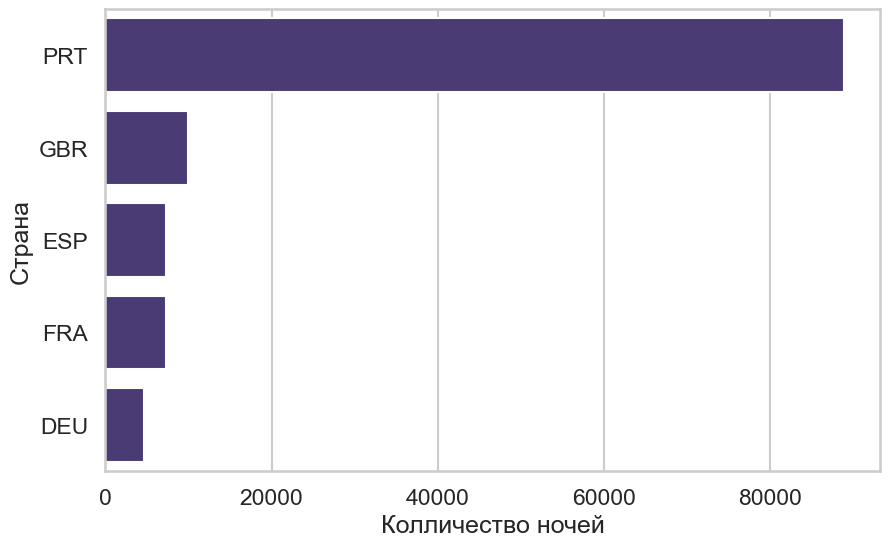

In [46]:
# 10. Оценка упущенной выгоды (Lost Nights)
# Топ-5 стран, генерирующих максимальные убытки (в ночах) при отменах
lost_nights_by_country = bookings.query('is_canceled == 1') \
    .groupby('country', as_index=False)['stays_total_nights'].sum() \
    .sort_values('stays_total_nights', ascending=False) \
    .head(5)
lost_nights_by_country
sns.barplot(lost_nights_by_country, x='stays_total_nights', y='country')
plt.xlabel('Колличество ночей')
plt.ylabel('Страна')
plt.show()
